<a target="_blank" href="https://colab.research.google.com/github/seap-udea/fargopy/blob/main/science/introducing-fargopy/notebooks/introducing-example-snippets.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<p align="left"><img src="https://github.com/seap-udea/fargopy/raw/refactor/docs/fargopy_logo.webp" width="300" /></p>

# FARGOpy: A Python Package for Post-processing and Analyzing FARGO3D Hydrodynamical Simulations

# Example snippets of the paper

In [1]:
try:
    from google.colab import drive
    %pip install -Uq git+https://github.com/seap-udea/fargopy
except ImportError:
    print("Not running in Colab, skipping installation")
    %load_ext autoreload
    %autoreload 2
!mkdir -p ./gallery/


Not running in Colab, skipping installation


## Snippets

### Basic codes

Running FARGOpy version 1.1.0. A major refactor has been done in versions 1.1.X. Please check the documentation for more information.
Precomputed output directory '/tmp/pds70iso' already exist
Your simulation is now connected with '/Users/jzuluaga/fargo3d/'
Now you are connected with output directory '/tmp/pds70iso'
Found a variables.par file in '/tmp/pds70iso', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 6
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.005024, 0.0], Mass: 0.005024
Units set to CGS.


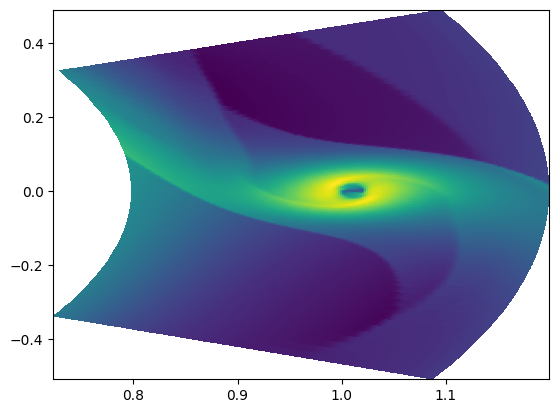

In [2]:
# Tested in version 1.1.X of FARGOpy
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt

sim_path = fp.Simulation.download_precomputed('pds70iso')
sim = fp.Simulation(output_dir=sim_path)
sim.units("CGS")

fields = sim.load_field(
    fields='gasdens',
    slice='r=[0.8,1.2],phi=[-25 deg,25 deg],theta=1.56',
    snapshot=200,
    coords='cartesian'
)

x = fields.var1_mesh[0]
y = fields.var2_mesh[0]
dens = fields.gasdens_mesh[0]
plt.pcolormesh(
     x, 
     y, 
     np.log10(dens.data)
)

### Interpolation

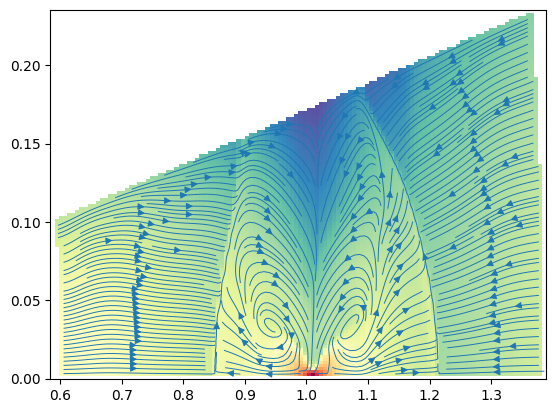

In [2]:
fields = sim.load_field(
    fields=['gasv','gasdens'],
    slice="r=[0.6,1.4], phi=0",
    snapshot=200
)

# Create the mesh grid for interpolation
X, Z = np.meshgrid(
    np.linspace(fields.var1_mesh[0].min(), 
                 fields.var1_mesh[0].max(), 120), 
    np.linspace(fields.var3_mesh[0].min(), 
                 fields.var3_mesh[0].max(), 120), 
    indexing='ij'
)

# Interpolate
gasdens_interp = fields.evaluate(
    field='gasdens', time=0, var1=X, var3=Z
)
velocity_interp = fields.evaluate(
    field='gasv', time=0, var1=X, var3=Z
)

# Colormesh of density
plt.pcolormesh(
    X, Z, np.log10(gasdens_interp),
    cmap='Spectral_r'
)
# Streamlines of velocity
plt.streamplot(
    X.T, Z.T, 
    velocity_interp[0].T, velocity_interp[2].T, 
    linewidth=0.7, density=3.0
)

### Flux and mass calculation

In [3]:
simpath = fp.Simulation.download_precomputed('p3disoj')
sim = fp.Simulation(output_dir=simpath)

# Load planet properties
planet = sim.load_planets(snapshot=10)[0]

# Define spherical surface at the Hill radius
sphere = fp.Surface(
    type="sphere",
    center=(planet.pos.x, planet.pos.y, planet.pos.z),
    radius=planet.hill_radius,
    subdivisions=6,
    z_cut=0.0
)

# Compute enclosed gas mass
mass = sphere.total_mass(
    sim,
    snapshot=[0,10],
    follow_planet=True
)

# Compute accreation rate
flux = sphere.mass_flux(
    sim=sim, 
    snapshot=[0,10],
    follow_planet=True
) 

Precomputed output directory '/tmp/p3disoj' already exist
Your simulation is now connected with '/Users/jzuluaga/fargo3d/'
Now you are connected with output directory '/tmp/p3disoj'
Found a variables.par file in '/tmp/p3disoj', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 128 [[0, np.float64(-3.117048960983623)], [-1, np.float64(3.117048960983623)]]
	Variable r: 64 [[0, np.float64(0.5078125)], [-1, np.float64(1.4921875)]]
	Variable theta: 32 [[0, np.float64(1.4231400767948967)], [-1, np.float64(1.5684525767948965)]]
Number of snapshots in output directory: 11
Planets found in summary.dat:
  Name: Jupiter, Initial pos: [1.0, 0.001, 0.0], Mass: 0.001


Calculating mass flux: 100%|██████████| 11/11 [00:27<00:00,  2.46s/it]


---
*Powered by fargopy*. For more examples see [fargopy GitHub repo](https://github.com/seap-udea/fargopy/tree/main/examples). 

Jorge I. Zuluaga, Alejandro Murillo-González and Matías Montesinos © 2023-present
